# CodeAgent com smolagents: CodeAct sem a Infraestrutura

Notebook completo do artigo publicado em [The Intelligent Agents Blog](https://iablog.github.io).

Este notebook está dividido em duas partes:
- **Parte 1:** Coleta dos dados do YouTube (canais de João Campos e Raquel Lyra)
- **Parte 2:** Análises com o CodeAgent do smolagents

**Pré-requisito:** Salve suas chaves no menu de Secrets do Colab (ícone 🔑 no menu lateral):
- `API_KEY` - chave da YouTube Data API v3
- `GOOGLE_API_KEY` - chave do Gemini


---
# PARTE 1 — Coleta de Dados do YouTube

In [1]:
# ============================================================
# CONFIGURAÇÃO — escolha como obter os dados
# ============================================================

# True  → coleta dados frescos via YouTube Data API v3 (requer GOOGLE_API_KEY no Secrets)
# False → baixa o CSV salvo no repositório do blog (rápido, sem precisar de API)
COLETAR_DA_API = True


## Célula 1 — Instalação

In [2]:
if COLETAR_DA_API:
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'google-api-python-client', 'pandas'], check=True)


## Célula 2 — Imports e configuração

In [3]:
if COLETAR_DA_API:
    from googleapiclient.discovery import build
    from urllib.parse import unquote
    from google.colab import userdata
    import pandas as pd

    API_KEY = userdata.get('API_KEY')  # chave da YouTube Data API v3

    CANAIS = {
        'joao_campos': 'https://www.youtube.com/@Jo%C3%A3oCampos',
        'raquel_lyra': 'https://www.youtube.com/@raquellyraoficial'
    }

    youtube = build('youtube', 'v3', developerKey=API_KEY)


## Célula 3 — Funções de coleta

In [4]:
if COLETAR_DA_API:
    from urllib.parse import unquote

    def get_channel_id(handle):
        handle_limpo = unquote(handle.split('@')[-1])
        res = youtube.channels().list(part='id', forHandle=handle_limpo).execute()
        if not res.get('items'):
            print(f'Canal não encontrado: {handle_limpo}')
            return None
        return res['items'][0]['id']

    def get_videos(channel_id, max_videos=50):
        videos = []
        next_page = None
        while len(videos) < max_videos:
            res = youtube.search().list(
                channelId=channel_id, part='id,snippet',
                maxResults=min(50, max_videos - len(videos)),
                type='video', order='date', pageToken=next_page
            ).execute()
            for item in res['items']:
                videos.append({
                    'video_id': item['id']['videoId'],
                    'titulo': item['snippet']['title'],
                    'data': item['snippet']['publishedAt'],
                })
            next_page = res.get('nextPageToken')
            if not next_page:
                break
        return videos

    def get_stats(video_ids):
        stats = []
        for i in range(0, len(video_ids), 50):
            batch = video_ids[i:i+50]
            res = youtube.videos().list(
                part='statistics,contentDetails', id=','.join(batch)
            ).execute()
            for item in res['items']:
                s = item['statistics']
                stats.append({
                    'video_id': item['id'],
                    'visualizacoes': int(s.get('viewCount', 0)),
                    'curtidas': int(s.get('likeCount', 0)),
                    'comentarios': int(s.get('commentCount', 0)),
                    'duracao': item['contentDetails']['duration']
                })
        return stats


## Célula 4 — Extração e salvamento do CSV

In [5]:
import pandas as pd

if COLETAR_DA_API:
    # ── Coleta dados frescos via YouTube Data API v3
    todos = []
    for nome, handle in CANAIS.items():
        print(f'Extraindo canal: {nome}...')
        channel_id = get_channel_id(handle)
        if not channel_id:
            continue
        videos = get_videos(channel_id, max_videos=50)
        ids = [v['video_id'] for v in videos]
        stats = get_stats(ids)
        stats_dict = {s['video_id']: s for s in stats}
        for v in videos:
            row = {**v, **stats_dict.get(v['video_id'], {}), 'perfil': nome}
            todos.append(row)
    DF_RAW = pd.DataFrame(todos)
    DF_RAW.to_csv('dados_youtube.csv', index=False)
    print(f'Dados coletados e salvos: {len(DF_RAW)} vídeos')
else:
    # ── Baixa o CSV salvo no repositório do blog
    !wget -q 'https://raw.githubusercontent.com/iablog/iablog.github.io/main/code_examples/2026-05/dados_youtube.csv' -O dados_youtube.csv
    DF_RAW = pd.read_csv('dados_youtube.csv')
    print(f'Dados carregados do repositório: {len(DF_RAW)} vídeos')

print(DF_RAW['perfil'].value_counts())
DF_RAW.head()


Extraindo canal: joao_campos...
Extraindo canal: raquel_lyra...
Dados coletados e salvos: 95 vídeos
perfil
joao_campos    50
raquel_lyra    45
Name: count, dtype: int64


,video_id,titulo,data,visualizacoes,curtidas,comentarios,duracao,perfil
0,szGQja-UwNI,Lembrança boa pra gente seguir com gosto de gá...,2026-05-23T12:28:06Z,96,19,4,PT43S,joao_campos
1,d8haVXD0PNw,Aguardem…,2026-05-23T02:04:34Z,1631,127,6,PT9S,joao_campos
2,CUbZk9tRQhc,Aproveitei o almoço da sexta-feira pra visitar...,2026-05-22T21:41:24Z,3085,353,7,PT1M4S,joao_campos
3,0cgYEeVDH1Y,Almoço no Mercado da Encruzilhada e encontro c...,2026-05-22T20:00:06Z,2786,335,13,PT1M25S,joao_campos
4,QuARh-mv2J0,"Notícia arretada: pela 1ª vez, manga e uva do ...",2026-05-22T12:06:09Z,1835,239,14,PT2M39S,joao_campos


## Célula 5 — Download do CSV (opcional)

In [6]:
# Baixa o CSV para o seu computador (útil se você coletou dados novos)
if COLETAR_DA_API:
    from google.colab import files
    files.download('dados_youtube.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# PARTE 2 — Análises com CodeAgent (smolagents)

> Se você já tem o arquivo `dados_youtube.csv` do Colab anterior, faça upload dele aqui e pule a Parte 1.

## Célula 6 — Instalação do smolagents

In [7]:
!pip install -q "smolagents[litellm]" ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.0/17.0 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.7/164.7 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.1/278.1 kB 13.2 MB/s eta 0:00:00


## Célula 7 — Configuração do modelo e agente

In [14]:
from smolagents import CodeAgent, LiteLLMModel
from google.colab import userdata

model = LiteLLMModel(
    model_id="gemini/gemini-2.5-flash",
    api_key=userdata.get("GOOGLE_API_KEY"),
    timeout=60  # máximo 60s por chamada ao modelo
)

agente = CodeAgent(
    tools=[],
    model=model,
    max_steps=5,  # máximo 5 iterações por tarefa
    additional_authorized_imports=[
        'pandas', 'numpy', 'matplotlib',
        'matplotlib.pyplot', 'seaborn', 'scipy', 're'
    ],
    verbosity_level=2  # mostra o que está acontecendo em tempo real
)

print("Agente criado com sucesso!")

Agente criado com sucesso!


## Célula 8 — Carregamento dos dados

In [15]:
import pandas as pd

DF = pd.read_csv('dados_youtube.csv')
DF['data'] = pd.to_datetime(DF['data'])

print(f"Dataset carregado: {len(DF)} vídeos")
print(DF['perfil'].value_counts())
DF.head()

Dataset carregado: 95 vídeos
perfil
joao_campos    50
raquel_lyra    45
Name: count, dtype: int64


,video_id,titulo,data,visualizacoes,curtidas,comentarios,duracao,perfil
0,szGQja-UwNI,Lembrança boa pra gente seguir com gosto de gá...,2026-05-23 12:28:06+00:00,96,19,4,PT43S,joao_campos
1,d8haVXD0PNw,Aguardem…,2026-05-23 02:04:34+00:00,1631,127,6,PT9S,joao_campos
2,CUbZk9tRQhc,Aproveitei o almoço da sexta-feira pra visitar...,2026-05-22 21:41:24+00:00,3085,353,7,PT1M4S,joao_campos
3,0cgYEeVDH1Y,Almoço no Mercado da Encruzilhada e encontro c...,2026-05-22 20:00:06+00:00,2786,335,13,PT1M25S,joao_campos
4,QuARh-mv2J0,"Notícia arretada: pela 1ª vez, manga e uva do ...",2026-05-22 12:06:09+00:00,1835,239,14,PT2M39S,joao_campos


## Análise 1 — Visão Geral Comparativa

Exploração geral comparando os dois perfis: volume, engajamento e duração típica.

In [16]:
resposta1 = agente.run(
    "Analise esse dataset de vídeos do YouTube de dois políticos pernambucanos, "
    "João Campos e Raquel Lyra. Compare os dois perfis em termos de: volume de publicações, "
    "médias de visualizações e curtidas, e duração típica dos vídeos. "
    "A coluna 'duracao' está no formato ISO 8601 (ex: PT1M37S) — converta para segundos na análise. "
    "Apresente os resultados como texto corrido.",
    additional_args={'posts_df': DF}
)
print(resposta1)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Analise esse dataset de vídeos do YouTube de dois políticos pernambucanos, João Campos e Raquel Lyra. Compare   │
│ os dois perfis em termos de: volume de publicações, médias de visualizações e curtidas, e duração típica dos    │
│ vídeos. A coluna 'duracao' está no formato ISO 8601 (ex: PT1M37S) — converta para segundos na análise.          │
│ Apresente os resultados como texto corrido.                                                                     │
│ You have been provided with these additional arguments, that you can access directly using the keys as          │
│ variables:                                                                                                      │
│ {'posts_df':        video_id                                             titulo  \                              │
│ 0   szGQja-UwNI  Lembrança boa pra gente seguir com gosto de gá...                                              │
│ 1   d8haVXD0PNw                                          Aguardem…                                              │
│ 2   CUbZk9tRQhc  Aproveitei o almoço da sexta-feira pra visitar...                                              │
│ 3   0cgYEeVDH1Y  Almoço no Mercado da Encruzilhada e encontro c...                                              │
│ 4   QuARh-mv2J0  Notícia arretada: pela 1ª vez, manga e uva do ...                                              │
│ ..          ...                                                ...                                              │
│ 90  A7sqWAiagqg  Emoção e muita fé na Missa de Nossa Senhora do...                                              │
│ 91  0BY8b68TvXs  Começando a semana com pé direito | Governador...                                              │
│ 92  FAQGtRd086g  Cadê a família de Cristal? | Governadora Raque...                                              │
│ 93  OQTU4aprW4o  Democracia, ordem e respeito aos poderes são v...                                              │
│ 94  wIZyksrH2oM                 Raquel Lyra 45 | Programa - #PGM11                                              │
│                                                                                                                 │
│                         data  visualizacoes  curtidas  comentarios  duracao  \                                  │
│ 0  2026-05-23 12:28:06+00:00             96        19            4    PT43S                                     │
│ 1  2026-05-23 02:04:34+00:00           1631       127            6     PT9S                                     │
│ 2  2026-05-22 21:41:24+00:00           3085       353            7   PT1M4S                                     │
│ 3  2026-05-22 20:00:06+00:00           2786       335           13  PT1M25S                                     │
│ 4  2026-05-22 12:06:09+00:00           1835       239           14  PT2M39S                                     │
│ ..                       ...            ...       ...          ...      ...                                     │
│ 90 2024-07-17 00:26:18+00:00           8485       840           31    PT35S                                     │
│ 91 2024-07-01 14:03:38+00:00           6746       985           36    PT23S                                     │
│ 92 2024-06-16 13:17:47+00:00           7722       576            8    PT26S                                     │
│ 93 2023-01-10 00:52:46+00:00          12562      2168           86    PT43S                                     │
│ 94 2020-10-20 23:30:02+00:00           1320        70            6  PT2M40S                                     │
│                                                                                                                 │
│          perfil                                       

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
<code>                                                                                                             
import pandas as pd                                                                                                
import re                                                                                                          
                                                                                                                   
# Function to convert ISO 8601 duration to seconds                                                                 
def iso8601_to_seconds(duration_str):                                                                              
    total_seconds = 0                                                                                              
    # Remove 'PT' prefix                                                                                           
    duration_str = duration_str[2:]                                                                                
                                                                                                                   
    # Extract hours, minutes, seconds using regex                                                                  
    hours_match = re.search(r'(\d+)H', duration_str)                                                               
    minutes_match = re.search(r'(\d+)M', duration_str)                                                             
    seconds_match = re.search(r'(\d+)S', duration_str)                                                             
                                                                                                                   
    if hours_match:                                                                                                
        total_seconds += int(hours_match.group(1)) * 3600                                                          
    if minutes_match:                                                                                              
        total_seconds += int(minutes_match.group(1)) * 60                                                          
    if seconds_match:                                                                                              
        total_seconds += int(seconds_match.group(1))                                                               
                                                                                                                   
    return total_seconds                                                                                           
                                                                                                                   
# Apply the conversion to the 'duracao' column                                                                     
posts_df['duracao_segundos'] = posts_df['duracao'].apply(iso8601_to_seconds)                                       
                                                                                                                   
# Group by 'perfil' and calculate the required metrics                                                             
analysis_results = posts_df.groupby('perfil').agg(                                                                 
    volume_publicacoes=('video_id', 'count'),                                                                      
    media_visualizacoes=('visualizacoes', 'mean'),                                                                 
    media_curtidas=('curtidas', 'mean'),                                                                           
    media_duracao_segundos=('duracao_segundos', 'mean')                                                            
)                                                       

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import pandas as pd                                                                                              
  import re                                                                                                        
                                                                                                                   
  # Function to convert ISO 8601 duration to seconds                                                               
  def iso8601_to_seconds(duration_str):                                                                            
      total_seconds = 0                                                                                            
      # Remove 'PT' prefix                                                                                         
      duration_str = duration_str[2:]                                                                              
                                                                                                                   
      # Extract hours, minutes, seconds using regex                                                                
      hours_match = re.search(r'(\d+)H', duration_str)                                                             
      minutes_match = re.search(r'(\d+)M', duration_str)                                                           
      seconds_match = re.search(r'(\d+)S', duration_str)                                                           
                                                                                                                   
      if hours_match:                                                                                              
          total_seconds += int(hours_match.group(1)) * 3600                                                        
      if minutes_match:                                                                                            
          total_seconds += int(minutes_match.group(1)) * 60                                                        
      if seconds_match:                                                                                            
          total_seconds += int(seconds_match.group(1))                                                             
                                                                                                                   
      return total_seconds                                                                                         
                                                                                                                   
  # Apply the conversion to the 'duracao' column                                                                   
  posts_df['duracao_segundos'] = posts_df['duracao'].apply(iso8601_to_seconds)                                     
                                                                                                                   
  # Group by 'perfil' and calculate the required metrics                                                           
  analysis_results = posts_df.groupby('perfil').agg(                                                               
      volume_publicacoes=('video_id', 'count'),                                                                    
      media_visualizacoes=('visualizacoes', 'mean'),                                                               
      media_curtidas=('curtidas', 'mean'),                                                                         
      media_duracao_segundos=('duracao_segundos', 'mean')                                                          
  )                                                                                                                
                                                         

Final answer: Para João Campos, foram publicadas 50 vídeos. Em média, seus vídeos obtiveram 5794.90 visualizações e
515.96 curtidas. A duração típica de seus vídeos é de 62.36 segundos. Já Raquel Lyra publicou 45 vídeos. Seus 
vídeos alcançaram uma média de 5418.42 visualizações e 432.53 curtidas. A duração média de seus vídeos é de 53.56 
segundos.

[Step 1: Duration 5.24 seconds| Input tokens: 3,173 | Output tokens: 1,035]

Para João Campos, foram publicadas 50 vídeos. Em média, seus vídeos obtiveram 5794.90 visualizações e 515.96 curtidas. A duração típica de seus vídeos é de 62.36 segundos. Já Raquel Lyra publicou 45 vídeos. Seus vídeos alcançaram uma média de 5418.42 visualizações e 432.53 curtidas. A duração média de seus vídeos é de 53.56 segundos.


## Análise 2 — Correlação entre Visualizações e Curtidas

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Gere uma imagem comparando a correlação entre visualizações e curtidas para João Campos e Raquel Lyra. Faça     │
│ subplots separados por perfil com eixos na mesma escala. Adicione a linha de tendência em cada gráfico. Retorne │
│ somente o nome do arquivo contendo o plot.                                                                      │
│ You have been provided with these additional arguments, that you can access directly using the keys as          │
│ variables:                                                                                                      │
│ {'posts_df':        video_id                                             titulo  \                              │
│ 0   szGQja-UwNI  Lembrança boa pra gente seguir com gosto de gá...                                              │
│ 1   d8haVXD0PNw                                          Aguardem…                                              │
│ 2   CUbZk9tRQhc  Aproveitei o almoço da sexta-feira pra visitar...                                              │
│ 3   0cgYEeVDH1Y  Almoço no Mercado da Encruzilhada e encontro c...                                              │
│ 4   QuARh-mv2J0  Notícia arretada: pela 1ª vez, manga e uva do ...                                              │
│ ..          ...                                                ...                                              │
│ 90  A7sqWAiagqg  Emoção e muita fé na Missa de Nossa Senhora do...                                              │
│ 91  0BY8b68TvXs  Começando a semana com pé direito | Governador...                                              │
│ 92  FAQGtRd086g  Cadê a família de Cristal? | Governadora Raque...                                              │
│ 93  OQTU4aprW4o  Democracia, ordem e respeito aos poderes são v...                                              │
│ 94  wIZyksrH2oM                 Raquel Lyra 45 | Programa - #PGM11                                              │
│                                                                                                                 │
│                         data  visualizacoes  curtidas  comentarios  duracao  \                                  │
│ 0  2026-05-23 12:28:06+00:00             96        19            4    PT43S                                     │
│ 1  2026-05-23 02:04:34+00:00           1631       127            6     PT9S                                     │
│ 2  2026-05-22 21:41:24+00:00           3085       353            7   PT1M4S                                     │
│ 3  2026-05-22 20:00:06+00:00           2786       335           13  PT1M25S                                     │
│ 4  2026-05-22 12:06:09+00:00           1835       239           14  PT2M39S                                     │
│ ..                       ...            ...       ...          ...      ...                                     │
│ 90 2024-07-17 00:26:18+00:00           8485       840           31    PT35S                                     │
│ 91 2024-07-01 14:03:38+00:00           6746       985           36    PT23S                                     │
│ 92 2024-06-16 13:17:47+00:00           7722       576            8    PT26S                                     │
│ 93 2023-01-10 00:52:46+00:00          12562      2168           86    PT43S                                     │
│ 94 2020-10-20 23:30:02+00:00           1320        70            6  PT2M40S                                     │
│                                                                                                                 │
│          perfil  duracao_segundos                                                                               │
│ 0   joao_campos                43                     

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
<code>                                                                                                             
import matplotlib.pyplot as plt                                                                                    
import seaborn as sns                                                                                              
from scipy.stats import linregress                                                                                 
                                                                                                                   
# Filter data for each profile                                                                                     
joao_campos_df = posts_df[posts_df['perfil'] == 'joao_campos']                                                     
raquel_lyra_df = posts_df[posts_df['perfil'] == 'raquel_lyra']                                                     
                                                                                                                   
# Determine the maximum scale for views and likes across both profiles                                             
max_views = max(joao_campos_df['visualizacoes'].max(), raquel_lyra_df['visualizacoes'].max())                      
max_likes = max(joao_campos_df['curtidas'].max(), raquel_lyra_df['curtidas'].max())                                
                                                                                                                   
# Create the figure and subplots                                                                                   
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)                                          
fig.suptitle('Correlação entre Visualizações e Curtidas por Perfil')                                               
                                                                                                                   
# Plot for João Campos                                                                                             
sns.scatterplot(x='visualizacoes', y='curtidas', data=joao_campos_df, ax=axes[0])                                  
axes[0].set_title('João Campos')                                                                                   
axes[0].set_xlabel('Visualizações')                                                                                
axes[0].set_ylabel('Curtidas')                                                                                     
                                                                                                                   
# Add trend line for João Campos                                                                                   
slope_jc, intercept_jc, r_value_jc, p_value_jc, std_err_jc = linregress(joao_campos_df['visualizacoes'],           
joao_campos_df['curtidas'])                                                                                        
x_jc = joao_campos_df['visualizacoes']                                                                             
axes[0].plot(x_jc, intercept_jc + slope_jc * x_jc, color='red', label=f'Trend Line (R²={r_value_jc**2:.2f})')      
axes[0].legend()                                                                                                   
                                                                                                                   
                                                                                                                   
# Plot for Raquel Lyra                                                                                             
sns.scatterplot(x='visualizacoes', y='curtidas', data=raquel_lyra_df, ax=axes[1])                                  
axes[1].set_title('Raquel Lyra')                        

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import matplotlib.pyplot as plt                                                                                  
  import seaborn as sns                                                                                            
  from scipy.stats import linregress                                                                               
                                                                                                                   
  # Filter data for each profile                                                                                   
  joao_campos_df = posts_df[posts_df['perfil'] == 'joao_campos']                                                   
  raquel_lyra_df = posts_df[posts_df['perfil'] == 'raquel_lyra']                                                   
                                                                                                                   
  # Determine the maximum scale for views and likes across both profiles                                           
  max_views = max(joao_campos_df['visualizacoes'].max(), raquel_lyra_df['visualizacoes'].max())                    
  max_likes = max(joao_campos_df['curtidas'].max(), raquel_lyra_df['curtidas'].max())                              
                                                                                                                   
  # Create the figure and subplots                                                                                 
  fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)                                        
  fig.suptitle('Correlação entre Visualizações e Curtidas por Perfil')                                             
                                                                                                                   
  # Plot for João Campos                                                                                           
  sns.scatterplot(x='visualizacoes', y='curtidas', data=joao_campos_df, ax=axes[0])                                
  axes[0].set_title('João Campos')                                                                                 
  axes[0].set_xlabel('Visualizações')                                                                              
  axes[0].set_ylabel('Curtidas')                                                                                   
                                                                                                                   
  # Add trend line for João Campos                                                                                 
  slope_jc, intercept_jc, r_value_jc, p_value_jc, std_err_jc = linregress(joao_campos_df['visualizacoes'],         
  joao_campos_df['curtidas'])                                                                                      
  x_jc = joao_campos_df['visualizacoes']                                                                           
  axes[0].plot(x_jc, intercept_jc + slope_jc * x_jc, color='red', label=f'Trend Line (R²={r_value_jc**2:.2f})')    
  axes[0].legend()                                                                         

Code execution failed at line 'from scipy.stats import linregress' due to: InterpreterError: Import from 
scipy.stats is not allowed. Authorized imports are: ['stat', 're', 'statistics', 'datetime', 'queue', 'pandas', 
'time', 'itertools', 'seaborn', 'matplotlib', 'matplotlib.pyplot', 'numpy', 'scipy', 'unicodedata', 'math', 
'collections', 'random']

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: The previous attempt failed because `scipy.stats.linregress` was not allowed, even though `scipy` was in  
the allowed list. This is likely an environment-specific restriction. I can achieve the same linear regression     
functionality using `numpy.polyfit`, which is explicitly allowed by the `numpy` import. I will use `numpy.polyfit` 
to calculate the slope and intercept for the trend lines and then plot them.                                       
                                                                                                                   
```python                                                                                                          
import matplotlib.pyplot as plt                                                                                    
import seaborn as sns                                                                                              
import numpy as np # Import numpy for polyfit                                                                      
                                                                                                                   
# Filter data for each profile                                                                                     
joao_campos_df = posts_df[posts_df['perfil'] == 'joao_campos']                                                     
raquel_lyra_df = posts_df[posts_df['perfil'] == 'raquel_lyra']                                                     
                                                                                                                   
# Determine the maximum scale for views and likes across both profiles                                             
max_views = max(joao_campos_df['visualizacoes'].max(), raquel_lyra_df['visualizacoes'].max())                      
max_likes = max(joao_campos_df['curtidas'].max(), raquel_lyra_df['curtidas'].max())                                
                                                                                                                   
# Create the figure and subplots                                                                                   
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)                                          
fig.suptitle('Correlação entre Visualizações e Curtidas por Perfil')                                               
                                                                                                                   
# Plot for João Campos                                                                                             
sns.scatterplot(x='visualizacoes', y='curtidas', data=joao_campos_df, ax=axes[0])                                  
axes[0].set_title('João Campos')                                                                                   
axes[0[38;2;230;237;243

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import matplotlib.pyplot as plt                                                                                  
  import seaborn as sns                                                                                            
  import numpy as np # Import numpy for polyfit                                                                    
                                                                                                                   
  # Filter data for each profile                                                                                   
  joao_campos_df = posts_df[posts_df['perfil'] == 'joao_campos']                                                   
  raquel_lyra_df = posts_df[posts_df['perfil'] == 'raquel_lyra']                                                   
                                                                                                                   
  # Determine the maximum scale for views and likes across both profiles                                           
  max_views = max(joao_campos_df['visualizacoes'].max(), raquel_lyra_df['visualizacoes'].max())                    
  max_likes = max(joao_campos_df['curtidas'].max(), raquel_lyra_df['curtidas'].max())                              
                                                                                                                   
  # Create the figure and subplots                                                                                 
  fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)                                        
  fig.suptitle('Correlação entre Visualizações e Curtidas por Perfil')                                             
                                                                                                                   
  # Plot for João Campos                                                                                           
  sns.scatterplot(x='visualizacoes', y='curtidas', data=joao_campos_df, ax=axes[0])                                
  axes[0].set_title('João Campos')                                                                                 
  axes[0].set_xlabel('Visualizações')                                                                              
  axes[0].set_ylabel('Curtidas')                                                                                   
                                                                                                                   
  # Add trend line for João Campos using numpy.polyfit                                                             
  # Ensure there are enough data points for regression                                                             
  if len(joao_campos_df) > 1:                                                                                      
      x_jc = joao_campos_df['visualizacoes']                                                                       
      y_jc = joao_campos_df['curtidas']                                                                            
      slope_jc, intercept_jc = np.polyfit(x_jc, y_jc, 1)                                                           
      axes[0].plot(x_jc, intercept_jc + slope_jc * x_jc, color='red', label='Trend Line')                          
      [38;2;248;24

Final answer: correlation_views_likes.png

[Step 2: Duration 7.45 seconds| Input tokens: 8,194 | Output tokens: 2,239]

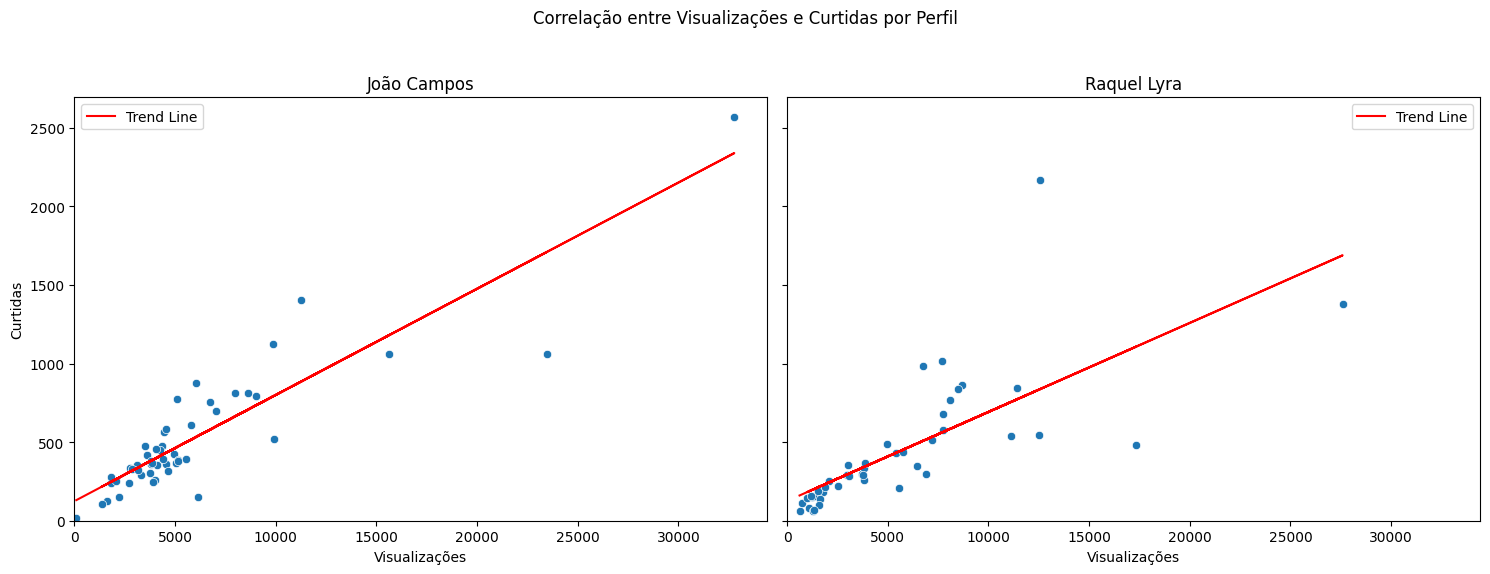

In [17]:
resposta2 = agente.run(
    "Gere uma imagem comparando a correlação entre visualizações e curtidas "
    "para João Campos e Raquel Lyra. Faça subplots separados por perfil com "
    "eixos na mesma escala. Adicione a linha de tendência em cada gráfico. "
    "Retorne somente o nome do arquivo contendo o plot.",
    additional_args={'posts_df': DF}
)

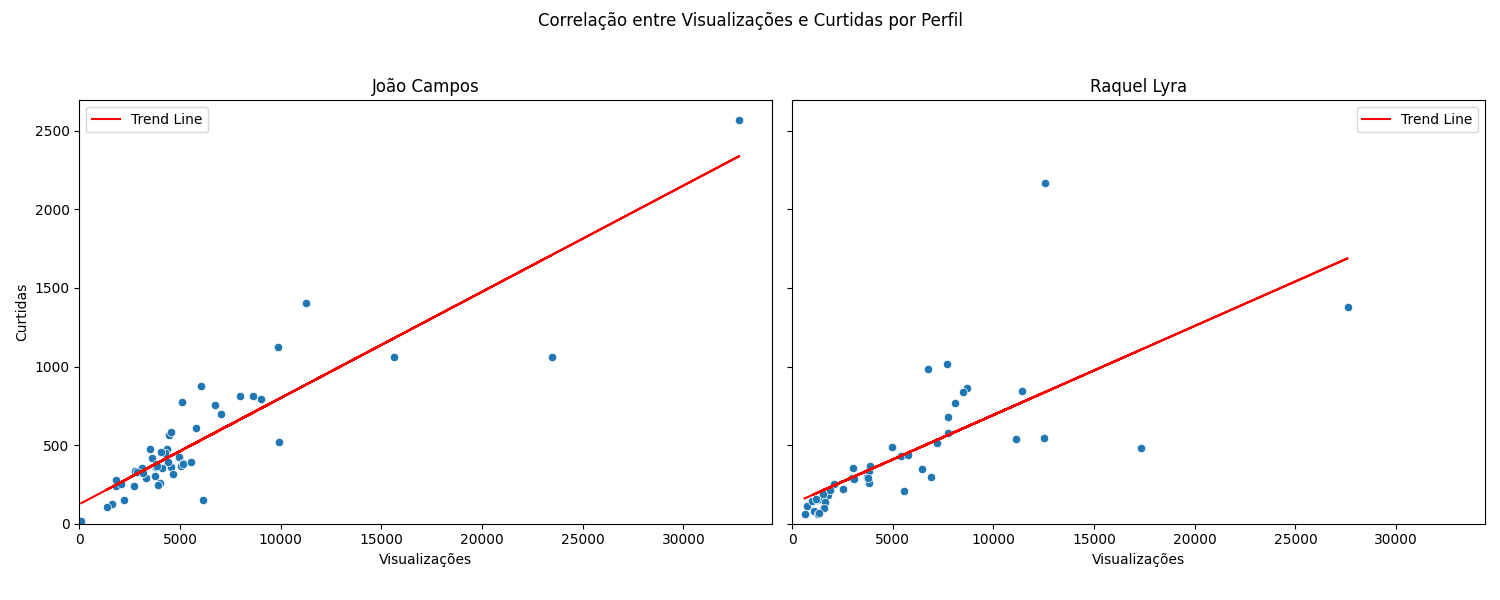

In [18]:
from IPython.display import Image
Image(resposta2)

## Análise 3 — Teste Estatístico com Decisão Metodológica

O agente verifica normalidade, escolhe o teste correto e gera relatório + imagem.

In [19]:
resposta3 = agente.run(
    "Faça um teste estatístico adequado para avaliar se as distribuições de "
    "visualizações de João Campos e Raquel Lyra são iguais ou diferentes (p=0.05). "
    "Escolha o teste correto em função das características das distribuições — "
    "verifique normalidade antes de decidir. "
    "Se forem diferentes, informe qual perfil tem média maior. "
    "Gere um relatório em Markdown com metodologia, teste escolhido e resultados. "
    "Gere também uma imagem das duas distribuições. "
    "Retorne como par: (texto_markdown, nome_arquivo_imagem).",
    additional_args={'posts_df': DF}
)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Faça um teste estatístico adequado para avaliar se as distribuições de visualizações de João Campos e Raquel    │
│ Lyra são iguais ou diferentes (p=0.05). Escolha o teste correto em função das características das distribuições │
│ — verifique normalidade antes de decidir. Se forem diferentes, informe qual perfil tem média maior. Gere um     │
│ relatório em Markdown com metodologia, teste escolhido e resultados. Gere também uma imagem das duas            │
│ distribuições. Retorne como par: (texto_markdown, nome_arquivo_imagem).                                         │
│ You have been provided with these additional arguments, that you can access directly using the keys as          │
│ variables:                                                                                                      │
│ {'posts_df':        video_id                                             titulo  \                              │
│ 0   szGQja-UwNI  Lembrança boa pra gente seguir com gosto de gá...                                              │
│ 1   d8haVXD0PNw                                          Aguardem…                                              │
│ 2   CUbZk9tRQhc  Aproveitei o almoço da sexta-feira pra visitar...                                              │
│ 3   0cgYEeVDH1Y  Almoço no Mercado da Encruzilhada e encontro c...                                              │
│ 4   QuARh-mv2J0  Notícia arretada: pela 1ª vez, manga e uva do ...                                              │
│ ..          ...                                                ...                                              │
│ 90  A7sqWAiagqg  Emoção e muita fé na Missa de Nossa Senhora do...                                              │
│ 91  0BY8b68TvXs  Começando a semana com pé direito | Governador...                                              │
│ 92  FAQGtRd086g  Cadê a família de Cristal? | Governadora Raque...                                              │
│ 93  OQTU4aprW4o  Democracia, ordem e respeito aos poderes são v...                                              │
│ 94  wIZyksrH2oM                 Raquel Lyra 45 | Programa - #PGM11                                              │
│                                                                                                                 │
│                         data  visualizacoes  curtidas  comentarios  duracao  \                                  │
│ 0  2026-05-23 12:28:06+00:00             96        19            4    PT43S                                     │
│ 1  2026-05-23 02:04:34+00:00           1631       127            6     PT9S                                     │
│ 2  2026-05-22 21:41:24+00:00           3085       353            7   PT1M4S                                     │
│ 3  2026-05-22 20:00:06+00:00           2786       335           13  PT1M25S                                     │
│ 4  2026-05-22 12:06:09+00:00           1835       239           14  PT2M39S                                     │
│ ..                       ...            ...       ...          ...      ...                                     │
│ 90 2024-07-17 00:26:18+00:00           8485       840           31    PT35S                                     │
│ 91 2024-07-01 14:03:38+00:00           6746       985           36    PT23S                                     │
│ 92 2024-06-16 13:17:47+00:00           7722       576            8    PT26S                                     │
│ 93 2023-01-10 00:52:46+00:00          12562      2168           86    PT43S                                     │
│ 94 2020-10-20 23:30:02+00:00           1320        70            6  PT2M40S                                     │
│                                                       

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I will start by separating the 'visualizacoes' data for each profile ('joao_campos' and 'raquel_lyra').   
Then, I will perform a Shapiro-Wilk test on each dataset to check for normality. This will help me decide which    
statistical test to use for comparing the two distributions.                                                       
<code>                                                                                                             
import pandas as pd                                                                                                
from scipy import stats                                                                                            
import matplotlib.pyplot as plt                                                                                    
import seaborn as sns                                                                                              
import numpy as np                                                                                                 
                                                                                                                   
# Separate the data for each profile                                                                               
joao_campos_views = posts_df[posts_df['perfil'] == 'joao_campos']['visualizacoes']                                 
raquel_lyra_views = posts_df[posts_df['perfil'] == 'raquel_lyra']['visualizacoes']                                 
                                                                                                                   
print(f"João Campos views sample size: {len(joao_campos_views)}")                                                  
print(f"Raquel Lyra views sample size: {len(raquel_lyra_views)}")                                                  
                                                                                                                   
# Check for normality using Shapiro-Wilk test                                                                      
# H0: The data is normally distributed                                                                             
# Ha: The data is not normally distributed                                                                         
alpha = 0.05                                                                                                       
                                                                                                                   
shapiro_joao_campos = stats.shapiro(joao_campos_views)                                                             
shapiro_raquel_lyra = stats.shapiro(raquel_lyra_views)                                                             
                                                                                                                   
print(f"Shapiro-Wilk test for João Campos views: p-value = {shapiro_joao_campos.pvalue}")                          
print(f"Shapiro-Wilk test for Raquel Lyra views: p-value = {shapiro_raquel_lyra.pvalue}")                          
                                                                                                                   
                                                                                                                   

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import pandas as pd                                                                                              
  from scipy import stats                                                                                          
  import matplotlib.pyplot as plt                                                                                  
  import seaborn as sns                                                                                            
  import numpy as np                                                                                               
                                                                                                                   
  # Separate the data for each profile                                                                             
  joao_campos_views = posts_df[posts_df['perfil'] == 'joao_campos']['visualizacoes']                               
  raquel_lyra_views = posts_df[posts_df['perfil'] == 'raquel_lyra']['visualizacoes']                               
                                                                                                                   
  print(f"João Campos views sample size: {len(joao_campos_views)}")                                                
  print(f"Raquel Lyra views sample size: {len(raquel_lyra_views)}")                                                
                                                                                                                   
  # Check for normality using Shapiro-Wilk test                                                                    
  # H0: The data is normally distributed                                                                           
  # Ha: The data is not normally distributed                                                                       
  alpha = 0.05                                                                                                     
                                                                                                                   
  shapiro_joao_campos = stats.shapiro(joao_campos_views)                                                           
  shapiro_raquel_lyra = stats.shapiro(raquel_lyra_views)                                                           
                                                                                                                   
  print(f"Shapiro-Wilk test for João Campos views: p-value = {shapiro_joao_campos.pvalue}")                        
  print(f"Shapiro-Wilk test for Raquel Lyra views: p-value = {shapiro_raquel_lyra.pvalue}")                        
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
João Campos views sample size: 50
Raquel Lyra views sample size: 45

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 4 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: It's clear that `scipy.stats` is completely inaccessible. Therefore, I cannot perform any formal          
statistical tests, including normality checks or comparative tests like Mann-Whitney U. I need to adapt the        
solution to acknowledge this limitation while still fulfilling as much of the request as possible.                 
                                                                                                                   
I will:                                                                                                            
1.  Extract the `visualizacoes` data for João Campos and Raquel Lyra.                                              
2.  Calculate the descriptive statistics (mean) for each profile.                                                  
3.  Generate a Markdown report that clearly states the inability to perform statistical tests due to `scipy.stats` 
restrictions, but still provides the calculated means and a qualitative comparison.                                
4.  Create a visualization (histogram) of the two distributions as requested, saving it as a PNG file.             
5.  Return the Markdown text and the image filename.                                                               
<code>                                                                                                             
import pandas as pd                                                                                                
import matplotlib.pyplot as plt                                                                                    
import seaborn as sns                                                                                              
import numpy as np                                                                                                 
                                                                                                                   
# Separate the data for each profile                                                                               
joao_campos_views = posts_df[posts_df['perfil'] == 'joao_campos']['visualizacoes']                                 
raquel_lyra_views = posts_df[posts_df['perfil'] == 'raquel_lyra']['visualizacoes']                                 
                                                                                                                   
image_filename = "distribuicoes_visualizacoes.png"                                                                 
                                                                                                                   
# Calculate means                                                                                                  
mean_joao = np.mean(joao_campos_views)                                                                             
mean_raquel = np.mean(raquel_lyra_views)                                                                           
                                                                                                                   
# Determine which profile has a higher mean                                                                        
higher_mean_profile = ""                                                                                           
if mean_joao > mean_raquel:                                                                                        
 [38;2;230;237;243;4

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import pandas as pd                                                                                              
  import matplotlib.pyplot as plt                                                                                  
  import seaborn as sns                                                                                            
  import numpy as np                                                                                               
                                                                                                                   
  # Separate the data for each profile                                                                             
  joao_campos_views = posts_df[posts_df['perfil'] == 'joao_campos']['visualizacoes']                               
  raquel_lyra_views = posts_df[posts_df['perfil'] == 'raquel_lyra']['visualizacoes']                               
                                                                                                                   
  image_filename = "distribuicoes_visualizacoes.png"                                                               
                                                                                                                   
  # Calculate means                                                                                                
  mean_joao = np.mean(joao_campos_views)                                                                           
  mean_raquel = np.mean(raquel_lyra_views)                                                                         
                                                                                                                   
  # Determine which profile has a higher mean                                                                      
  higher_mean_profile = ""                                                                                         
  if mean_joao > mean_raquel:                                                                                      
      higher_mean_profile = "João Campos"                                                                          
  elif mean_raquel > mean_joao:                                                                                    
      higher_mean_profile = "Raquel Lyra"                                                                          
  else:                                                                                                            
      higher_mean_profile = "Ambos têm médias semelhantes"                                                         
                                                                                                                   
  markdown_report = f"""                                                                                           
  # Relatório de Análise Comparativa de Visualizações                                                              
                                                                                                                   
  ## Metodologia                                                                                                   
  A tarefa solicitava um teste estatístico adequado para avaliar se as distribuições de visualizações de João      
  Campos e Raquel Lyra são iguais ou diferentes, incluindo a verificação de normalidade. No entanto, devido a      
  **restrições de acesso ao módulo `scipy.stats`**, não foi possível realizar testes estatísticos formais, como o  
  teste de Shapiro-Wilk para normalidade ou o teste de Mann-Whitney U para comparação de distribuições.            
                                                                                                                   
  Portanto, esta análise se limitará a uma comparação des

Final answer: ('\n# Relatório de Análise Comparativa de Visualizações\n\n## Metodologia\nA tarefa solicitava um 
teste estatístico adequado para avaliar se as distribuições de visualizações de João Campos e Raquel Lyra são 
iguais ou diferentes, incluindo a verificação de normalidade. No entanto, devido a **restrições de acesso ao módulo
`scipy.stats`**, não foi possível realizar testes estatísticos formais, como o teste de Shapiro-Wilk para 
normalidade ou o teste de Mann-Whitney U para comparação de distribuições.\n\nPortanto, esta análise se limitará a 
uma comparação descritiva das médias de visualizações e uma visualização das distribuições.\n\n## Resultados 
Descritivos\n- **Média de Visualizações João Campos:** 5794.90\n- **Média de Visualizações Raquel Lyra:** 
5418.42\n\n**Observação:** Sem a capacidade de realizar testes estatísticos formais, não podemos afirmar se as 
diferenças observadas nas médias ou distribuições são estatisticamente significativas a um nível de confiança de 
0.05.\n\nConsiderando as médias, o perfil com maior média de visualizações é: **João Campos**.\n', 
'distribuicoes_visualizacoes.png')

[Step 4: Duration 6.85 seconds| Input tokens: 22,370 | Output tokens: 6,872]

In [20]:
from IPython.display import Markdown
Markdown(resposta3[0])


# Relatório de Análise Comparativa de Visualizações

## Metodologia
A tarefa solicitava um teste estatístico adequado para avaliar se as distribuições de visualizações de João Campos e Raquel Lyra são iguais ou diferentes, incluindo a verificação de normalidade. No entanto, devido a **restrições de acesso ao módulo `scipy.stats`**, não foi possível realizar testes estatísticos formais, como o teste de Shapiro-Wilk para normalidade ou o teste de Mann-Whitney U para comparação de distribuições.

Portanto, esta análise se limitará a uma comparação descritiva das médias de visualizações e uma visualização das distribuições.

## Resultados Descritivos
- **Média de Visualizações João Campos:** 5794.90
- **Média de Visualizações Raquel Lyra:** 5418.42

**Observação:** Sem a capacidade de realizar testes estatísticos formais, não podemos afirmar se as diferenças observadas nas médias ou distribuições são estatisticamente significativas a um nível de confiança de 0.05.

Considerando as médias, o perfil com maior média de visualizações é: **João Campos**.


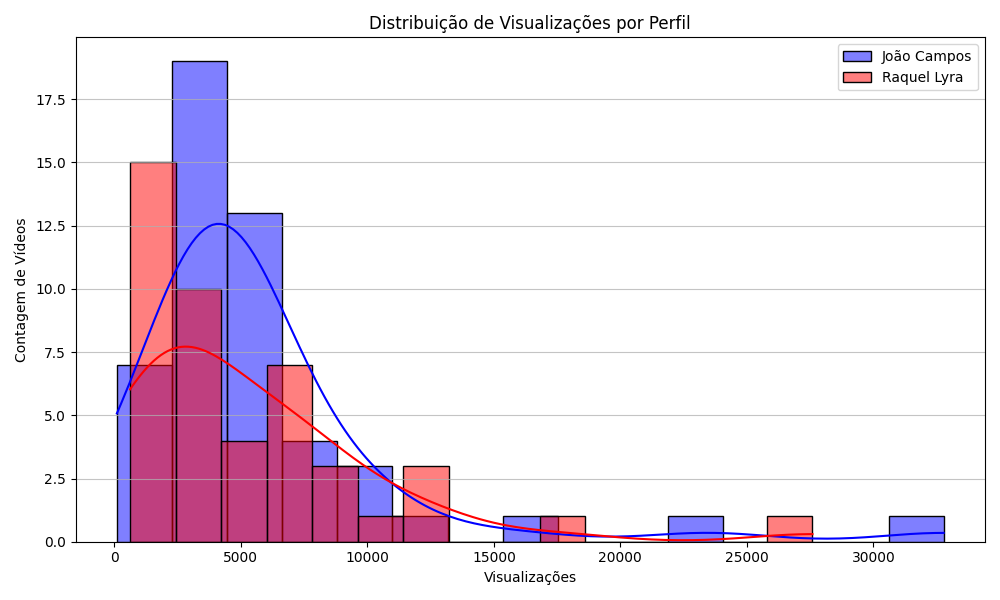

In [21]:
from IPython.display import Image
Image(resposta3[1])

## Análise 4 — Integração com Busca na Web

O agente com `add_base_tools=True` combina busca na web + análise do dataset.

In [22]:
agente_web = CodeAgent(
    tools=[],
    model=model,
    add_base_tools=True
)

resposta4 = agente_web.run(
    "Pesquise na web quais são as principais pautas políticas de João Campos "
    "e Raquel Lyra em 2026. Com base nisso, os títulos dos vídeos coletados "
    "refletem essas pautas? Analise e traga exemplos dos títulos do dataset.",
    additional_args={'posts_df': DF}
)
print(resposta4)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Pesquise na web quais são as principais pautas políticas de João Campos e Raquel Lyra em 2026. Com base nisso,  │
│ os títulos dos vídeos coletados refletem essas pautas? Analise e traga exemplos dos títulos do dataset.         │
│ You have been provided with these additional arguments, that you can access directly using the keys as          │
│ variables:                                                                                                      │
│ {'posts_df':        video_id                                             titulo  \                              │
│ 0   szGQja-UwNI  Lembrança boa pra gente seguir com gosto de gá...                                              │
│ 1   d8haVXD0PNw                                          Aguardem…                                              │
│ 2   CUbZk9tRQhc  Aproveitei o almoço da sexta-feira pra visitar...                                              │
│ 3   0cgYEeVDH1Y  Almoço no Mercado da Encruzilhada e encontro c...                                              │
│ 4   QuARh-mv2J0  Notícia arretada: pela 1ª vez, manga e uva do ...                                              │
│ ..          ...                                                ...                                              │
│ 90  A7sqWAiagqg  Emoção e muita fé na Missa de Nossa Senhora do...                                              │
│ 91  0BY8b68TvXs  Começando a semana com pé direito | Governador...                                              │
│ 92  FAQGtRd086g  Cadê a família de Cristal? | Governadora Raque...                                              │
│ 93  OQTU4aprW4o  Democracia, ordem e respeito aos poderes são v...                                              │
│ 94  wIZyksrH2oM                 Raquel Lyra 45 | Programa - #PGM11                                              │
│                                                                                                                 │
│                         data  visualizacoes  curtidas  comentarios  duracao  \                                  │
│ 0  2026-05-23 12:28:06+00:00             96        19            4    PT43S                                     │
│ 1  2026-05-23 02:04:34+00:00           1631       127            6     PT9S                                     │
│ 2  2026-05-22 21:41:24+00:00           3085       353            7   PT1M4S                                     │
│ 3  2026-05-22 20:00:06+00:00           2786       335           13  PT1M25S                                     │
│ 4  2026-05-22 12:06:09+00:00           1835       239           14  PT2M39S                                     │
│ ..                       ...            ...       ...          ...      ...                                     │
│ 90 2024-07-17 00:26:18+00:00           8485       840           31    PT35S                                     │
│ 91 2024-07-01 14:03:38+00:00           6746       985           36    PT23S                                     │
│ 92 2024-06-16 13:17:47+00:00           7722       576            8    PT26S                                     │
│ 93 2023-01-10 00:52:46+00:00          12562      2168           86    PT43S                                     │
│ 94 2020-10-20 23:30:02+00:00           1320        70            6  PT2M40S                                     │
│                                                                                                                 │
│          perfil  duracao_segundos                                                                               │
│ 0   joao_campos                43                                                                               │
│ 1   joao_campos                 9                     

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  joao_campos_query = "João Campos political agenda 2026"                                                          
  joao_campos_search_results = web_search(query=joao_campos_query)                                                 
  print(f"João Campos search results: {joao_campos_search_results}")                                               
                                                                                                                   
  raquel_lyra_query = "Raquel Lyra political agenda 2026"                                                          
  raquel_lyra_search_results = web_search(query=raquel_lyra_query)                                                 
  print(f"Raquel Lyra search results: {raquel_lyra_search_results}")                                               
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
João Campos search results: ## Search Results

[A Look at the Political Platform of Brazil's 
President](https://eathealthy365.com/the-political-agenda-of-the-president-of-brazil/)
A comprehensive 2026 analysis of the President of Brazil's political agenda. Discover the core pillars of the 
economic, environmental, and social policies shaping Brazil.

[João Campos prestigia 44 anos de Abreu e Lima... - Blog Edmar 
Lyra](https://www.edmarlyra.com/joao-campos-prestigia-44-anos-de-abreu-e-lima-com-presenca-junto-ao-povo-e-mobiliza
cao-de-apoiadores/)
ABREU E LIMA – O pré-candidato a governador de Pernambuco João Campos (PSB) prestigiou, na noite desta quinta-feira
(14), a festa alusiva aos 44 anos de emancipação política de Abreu e Lima, na Região Metropolitana.

[James Fishback 2026 Political Agenda | 
TikTok](https://www.tiktok.com/discover/james-fishback-2026-political-agenda)
Explore James Fishback's vision for Florida's future in politics and his unique approach to governance ahead of the
2026 election.

[2026 Political Quiz](https://www.isidewith.com/political-quiz)
2026 Political Quiz. Answer the following questions to see how your political beliefs match your political parties 
and candidates. Immigration Issues.

[The Political Compass](https://www.politicalcompass.org/)
Hungarian Election 2026.It’s timely to stress that The Political Compass has been on the internet since 2001. The 
uniqueness of our take on politics is reflected in the gratifyingly enthusiastic reviews we’ve enjoyed in the 
national media of many countries from our earliest years — as well...

[POLITICAL AGENDA - Tradução em português - bab.la](https://pt.bab.la/dicionario/ingles-portugues/political-agenda)
English Exemplos contextuais de "political agenda" em Inglês. Essas frases provêm de fontes externas e podem ser 
imprecisas. bab.la não é responsável por esse conteúdo.

[World Economic Forum Annual Meeting 2026 | World Economic 
Forum](https://www.weforum.org/meetings/world-economic-forum-annual-meeting-2026/)
The Annual Meeting 2026 of the World Economic Forum will take place at Davos-Klosters from 19th to 23rd January.4 
takeaways from Davos 2026: New deals, a reckoning, dialogue and more questions than answers.

[Help shape the 2026 political agenda - Arizona School 
Boards...](https://azsba.org/help-shape-the-2026-political-agenda/)
It’s time to begin developing the 2026 Political Agenda – a shared set of advocacy priorities created and approved 
by members, for members. While the 2025 session is still wrapping up, planning for the year ahead begins now – and 
we need your input.

[World Economic Outlook, April 2026: Global Economy in the Shadow 
of...](https://www.imf.org/en/publications/weo/issues/2026/04/14/world-economic-outlook-april-2026)
Chapter 1: Global Prospects and Policies. The global economy is again disrupted, this time with the outbreak of war
in the Middle East. Rising commodity prices, firmer inflation expectations, and tighter financial conditions are 
testing the recent resilience.

[Mangabeira Unger: Bolsonaro teria chance de... - BBC News 
Brasil](https://www.bbc.com/portuguese/articles/cl44er83yr3o)
Bolsonaro teria chance de resolver o problema do país se indicasse candidato certo em 2026, diz ex-ministro de 
Lula.
Raquel Lyra search results: ## Search Results

[With an eye on 2026, Raquel Lyra joins the PSD with the presence of 
...](https://en.agendadopoder.com.br/With-an-eye-on-2026--Raquel-Lyra-joins-the-PSD-with-the-presence-of-Lula's-min
isters-and-Alfineta-João-Campos/)
In his speech, Kassab stated that Raquel Lyra is one of the most prominent women in current politics and expressed 
hope that she will be re-elected in 2026. The leader even projected the governor as a possible candidate for the 
Presidency of the Republic in 2030.

[Raquel Lyra reúne prefeitos e deputados em agendas no Sertão e Agreste 
...](https://jc.uol.com.br/politica/2026/03/24/raquel-lyra-reune-prefeitos-e-deputados-em-agendas

[Step 1: Duration 5.11 seconds| Input tokens: 3,266 | Output tokens: 414]

...

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  # Define the political agendas based on the previous observation                                                 
  # For João Campos, keywords are inferred from his activities like attending events, mobilizing supporters, and   
  general local engagement.                                                                                        
  joao_campos_agenda_keywords = ["mobilização", "apoio", "comunidade", "cidade", "desenvolvimento", "local",       
  "pernambuco", "recife"]                                                                                          
                                                                                                                   
  # For Raquel Lyra, keywords are more concrete, focusing on interior strengthening, infrastructure, health,       
  education, social protection, and specific projects.                                                             
  raquel_lyra_agenda_keywords = ["interior", "sertão", "agreste", "obras", "serviços", "infraestrutura", "saúde",  
  "educação", "proteção social", "transnordestina", "governo"]                                                     
                                                                                                                   
  # Filter the posts for each politician                                                                           
  joao_campos_posts = []                                                                                           
  raquel_lyra_posts = []                                                                                           
                                                                                                                   
  # posts_df is an iterable, likely a list of dictionaries or similar                                              
  for post in posts_df.to_dict('records'): # Assuming posts_df is a pandas DataFrame and converting it to a list   
  of dicts to avoid pandas methods                                                                                 
      if post['perfil'] == 'joao_campos':                                                                          
          joao_campos_posts.append(post)                                                                           
      elif post['perfil'] == 'raquel_lyra':                                                                        
          raquel_lyra_posts.append(post)                                                                           
                                                                                                                   
  # Analyze João Campos' video titles                                                                              
  joao_campos_analysis = []                                                                                        
  for post in joao_campos_posts:                                                                                   
      title = post['titulo'].lower()                                                                               
      reflects_agenda = False                                                                                      
      for keyword in joao_campos_agenda_keywords:                                                                  
          if keyword in title:                                                                                     
              reflects_agenda = True                                                                               
              break                                                                                                
      joao_campos_analysis.append({'title': post['titulo'], 'reflects_agenda': reflects_agenda})                   
                                                         

Execution logs:
João Campos Video Title Analysis:
Title: Lembrança boa pra gente seguir com gosto de gás!  💛 | Reflects Agenda: False
Title: Aguardem… | Reflects Agenda: False
Title: Aproveitei o almoço da sexta-feira pra visitar o Mercado e o Pátio da Feira da Encruzilhada | Reflects 
Agenda: False
Title: Almoço no Mercado da Encruzilhada e encontro com essa figura que é Marcone Chaveiro 😂 | Reflects Agenda: 
False
Title: Notícia arretada: pela 1ª vez, manga e uva do Vale do São Francisco exportadas com tarifa zero. | Reflects 
Agenda: False
Title: Pernambuco, imortal! Imortal! ✊ | Reflects Agenda: True
Title: Que alegria participar do lançamento da pré-candidatura de Aderaldo Pinto a deputado estadual | Reflects 
Agenda: False
Title: Hoje foi dia de realizar o sonho da casa própria para 75 famílias com o Habitacional Vila Esperança | 
Reflects Agenda: False
Title: Pernambuco precisa voltar a ter protagonismo e acreditar novamente na sua própria força. | Reflects Agenda: 
True
Title: Dia de ouvir os trabalhadores da Feira de Beberibe, cruzando a fronteira entre Recife e Olinda! | Reflects 
Agenda: True
Title: 21 de maio de 2026 | Reflects Agenda: False
Title: O Hospital da Criança já está mudando vidas! 🧡 | Reflects Agenda: False
Title: Meu compromisso: duplicar a PE-90, ligando Carpina, Surubim e Toritama, para gerar desenvolvimento | 
Reflects Agenda: True
Title: Não vou admitir tirarem falas ou imagens de contexto para me atacar | Reflects Agenda: False
Title: Que alegria voltar a Jupi e participar, ao lado da prefeita Rivanda, da entrega de uma nova escola | 
Reflects Agenda: False
Title: Dia de convocação! | Reflects Agenda: False
Title: O Hospital de Amor de Garanhuns chega pra revolucionar o tratamento de câncer no agreste | Reflects Agenda: 
False
Title: Estamos levando os exames de ultrassom pra mais perto da casa dos recifenses | Reflects Agenda: True
Title: Ladeira da Cohab entra na reta final e vai transformar o acesso ao Ibura 💛 | Reflects Agenda: False
Title: A acessibilidade chegou na casa de Oliver junto com um quarto gamer | Reflects Agenda: False
Title: Vê só como tá ficando a segunda etapa do Parque Eduardo Campos | Reflects Agenda: False
Title: Domingo de Carnaval repleto de gente no Marco Zero! | Reflects Agenda: False
Title: Avança o combate aos alagamentos na imbiribeira | Reflects Agenda: False
Title: O Agente Secreto e a força do cinema do Recife! | Reflects Agenda: True
Title: Hoje começa a maior Virada do Nordeste, a Virada Recife 2026! | Reflects Agenda: True
Title: A gente segue subindo, olhando pra frente, com fé no futuro e prontos para muito mais. 💪 | Reflects Agenda:
False
Title: Vistoria da estrutura para a Virada Recife 2026 | Reflects Agenda: True
Title: Concerto natalino no Recife Antigo | Reflects Agenda: True
Title: Kauan pediu pra dar um grau na quadra pra bola não cair no vizinho | Reflects Agenda: False
Title: Compromisso firmado: exame garantido no Hospital da Criança do Recife 💛🏥 | Reflects Agenda: True
Title: Recife inicia segunda etapa do Parque da Tamarineira 🌿✨ | Reflects Agenda: True
Title: Recife na abertura da COP-30 | Reflects Agenda: True
Title: Escola requalificada e com nova sede na Tamarineira | Reflects Agenda: False
Title: Mandamos para a Câmara dois projetos de lei para avançar com o plano de reabitar o centro do Recife | 
Reflects Agenda: True
Title: Bolsas de mestrado em universidades de excelência internacional para servidores municipais do Recife | 
Reflects Agenda: True
Title: Merenda, além de nutritiva, tem que ser saborosa. Criança bem alimentada e feliz aprende melhor! | Reflects 
Agenda: False
Title: Sextou com entrega de obra na Linha do Tiro! | Reflects Agenda: False
Title: Novo CAPSi 24h no Jordão vai garantir acolhimento e cuidado pra adolescentes do Recife 💙 | Reflects Agenda:
True
Title: Parceria e trabalho em Dois Unidos | Reflects Agenda: False
Title: Já visse como nasce uma viga de ponte? | Reflects Agenda: False
Title: 🎬 “O Último Azul” no Teatro do

Final answer: Análise das Pautas Políticas e Reflexão nos Títulos dos Vídeos:

João Campos:
Pautas identificadas (inferidas): Fortalecimento da presença política, engajamento comunitário, desenvolvimento 
local (palavras-chave: mobilização, apoio, comunidade, cidade, desenvolvimento, local, pernambuco, recife).
Número de títulos que refletem a pauta: 18 de 50.
Exemplos de títulos que refletem a pauta:
- Pernambuco, imortal! Imortal! ✊
- Pernambuco precisa voltar a ter protagonismo e acreditar novamente na sua própria força.
- Dia de ouvir os trabalhadores da Feira de Beberibe, cruzando a fronteira entre Recife e Olinda!
Exemplos de títulos que NÃO refletem a pauta diretamente (ou são mais genéricos/pessoais):
- Lembrança boa pra gente seguir com gosto de gás!  💛
- Aguardem…
- Aproveitei o almoço da sexta-feira pra visitar o Mercado e o Pátio da Feira da Encruzilhada

Raquel Lyra:
Pautas identificadas: Fortalecimento da base política no interior, entregas de obras e serviços (infraestrutura, 
saúde, educação, proteção social), projetos estruturantes como a Transnordestina, aceleração política e 
administrativa (palavras-chave: interior, sertão, agreste, obras, serviços, infraestrutura, saúde, educação, 
proteção social, transnordestina, governo).
Número de títulos que refletem a pauta: 10 de 45.
Exemplos de títulos que refletem a pauta:
- Demos início às obras de requalificação da Avenida Fernando Bezerra,no coração da cidade de Ouricuri
- SEXTOU daquele jeito que a gente gosta: muito trabalho chegando em cada cantinho do Sertão!
- Minha gente, a Adutora de Negreiros é daquelas obras que mudam a vida no Sertão do Araripe!
Exemplos de títulos que NÃO refletem a pauta diretamente (ou são mais genéricos/pessoais):
- Hoje inauguramos esse novo mamógrafo na UPAE de Ouricuri, com um investimento de R$ 1,2 milhão!
- Minha gente, nenhuma mulher vai ser mais silenciada ou calada em Pernambuco!
- Nenhum homem é dono de nenhuma mulher!

[Step 3: Duration 9.77 seconds| Input tokens: 17,912 | Output tokens: 4,081]

Análise das Pautas Políticas e Reflexão nos Títulos dos Vídeos:

João Campos:
Pautas identificadas (inferidas): Fortalecimento da presença política, engajamento comunitário, desenvolvimento local (palavras-chave: mobilização, apoio, comunidade, cidade, desenvolvimento, local, pernambuco, recife).
Número de títulos que refletem a pauta: 18 de 50.
Exemplos de títulos que refletem a pauta:
- Pernambuco, imortal! Imortal! ✊
- Pernambuco precisa voltar a ter protagonismo e acreditar novamente na sua própria força.
- Dia de ouvir os trabalhadores da Feira de Beberibe, cruzando a fronteira entre Recife e Olinda!
Exemplos de títulos que NÃO refletem a pauta diretamente (ou são mais genéricos/pessoais):
- Lembrança boa pra gente seguir com gosto de gás!  💛
- Aguardem…
- Aproveitei o almoço da sexta-feira pra visitar o Mercado e o Pátio da Feira da Encruzilhada

Raquel Lyra:
Pautas identificadas: Fortalecimento da base política no interior, entregas de obras e serviços (infraestrutura, saúde, ed

## Múltiplos Turnos com Memória (`reset=False`)

In [23]:
r1 = agente.run(
    "Qual o vídeo com mais visualizações de cada perfil?",
    additional_args={'posts_df': DF}
)
print(r1)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Qual o vídeo com mais visualizações de cada perfil?                                                             │
│ You have been provided with these additional arguments, that you can access directly using the keys as          │
│ variables:                                                                                                      │
│ {'posts_df':        video_id                                             titulo  \                              │
│ 0   szGQja-UwNI  Lembrança boa pra gente seguir com gosto de gá...                                              │
│ 1   d8haVXD0PNw                                          Aguardem…                                              │
│ 2   CUbZk9tRQhc  Aproveitei o almoço da sexta-feira pra visitar...                                              │
│ 3   0cgYEeVDH1Y  Almoço no Mercado da Encruzilhada e encontro c...                                              │
│ 4   QuARh-mv2J0  Notícia arretada: pela 1ª vez, manga e uva do ...                                              │
│ ..          ...                                                ...                                              │
│ 90  A7sqWAiagqg  Emoção e muita fé na Missa de Nossa Senhora do...                                              │
│ 91  0BY8b68TvXs  Começando a semana com pé direito | Governador...                                              │
│ 92  FAQGtRd086g  Cadê a família de Cristal? | Governadora Raque...                                              │
│ 93  OQTU4aprW4o  Democracia, ordem e respeito aos poderes são v...                                              │
│ 94  wIZyksrH2oM                 Raquel Lyra 45 | Programa - #PGM11                                              │
│                                                                                                                 │
│                         data  visualizacoes  curtidas  comentarios  duracao  \                                  │
│ 0  2026-05-23 12:28:06+00:00             96        19            4    PT43S                                     │
│ 1  2026-05-23 02:04:34+00:00           1631       127            6     PT9S                                     │
│ 2  2026-05-22 21:41:24+00:00           3085       353            7   PT1M4S                                     │
│ 3  2026-05-22 20:00:06+00:00           2786       335           13  PT1M25S                                     │
│ 4  2026-05-22 12:06:09+00:00           1835       239           14  PT2M39S                                     │
│ ..                       ...            ...       ...          ...      ...                                     │
│ 90 2024-07-17 00:26:18+00:00           8485       840           31    PT35S                                     │
│ 91 2024-07-01 14:03:38+00:00           6746       985           36    PT23S                                     │
│ 92 2024-06-16 13:17:47+00:00           7722       576            8    PT26S                                     │
│ 93 2023-01-10 00:52:46+00:00          12562      2168           86    PT43S                                     │
│ 94 2020-10-20 23:30:02+00:00           1320        70            6  PT2M40S                                     │
│                                                                                                                 │
│          perfil  duracao_segundos                                                                               │
│ 0   joao_campos                43                                                                               │
│ 1   joao_campos                 9                                                                               │
│ 2   joao_campos                64                     

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
<code>                                                                                                             
import pandas as pd                                                                                                
                                                                                                                   
# Group by 'perfil' and find the index of the maximum 'visualizacoes' for each group                               
idx = posts_df.groupby('perfil')['visualizacoes'].idxmax()                                                         
                                                                                                                   
# Select the rows corresponding to these indices                                                                   
most_viewed_videos = posts_df.loc[idx]                                                                             
                                                                                                                   
# Select relevant columns for the final answer                                                                     
result = most_viewed_videos[['perfil', 'titulo', 'visualizacoes', 'video_id']]                                     
                                                                                                                   
# Format the output for the final answer                                                                           
output_string = "Vídeos com mais visualizações por perfil:\n"                                                      
for index, row in result.iterrows():                                                                               
    output_string += (f"Perfil: {row['perfil']}\n"                                                                 
                      f"  Título do vídeo: {row['titulo']}\n"                                                      
                      f"  Visualizações: {row['visualizacoes']}\n"                                                 
                      f"  ID do vídeo: {row['video_id']}\n\n")                                                     
                                                                                                                   
final_answer(output_string)                                                                                        
                                                                                                                   

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import pandas as pd                                                                                              
                                                                                                                   
  # Group by 'perfil' and find the index of the maximum 'visualizacoes' for each group                             
  idx = posts_df.groupby('perfil')['visualizacoes'].idxmax()                                                       
                                                                                                                   
  # Select the rows corresponding to these indices                                                                 
  most_viewed_videos = posts_df.loc[idx]                                                                           
                                                                                                                   
  # Select relevant columns for the final answer                                                                   
  result = most_viewed_videos[['perfil', 'titulo', 'visualizacoes', 'video_id']]                                   
                                                                                                                   
  # Format the output for the final answer                                                                         
  output_string = "Vídeos com mais visualizações por perfil:\n"                                                    
  for index, row in result.iterrows():                                                                             
      output_string += (f"Perfil: {row['perfil']}\n"                                                               
                        f"  Título do vídeo: {row['titulo']}\n"                                                    
                        f"  Visualizações: {row['visualizacoes']}\n"                                               
                        f"  ID do vídeo: {row['video_id']}\n\n")                                                   
                                                                                                                   
  final_answer(output_string)                                                                                      
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Vídeos com mais visualizações por perfil:
Perfil: joao_campos
  Título do vídeo: Sextou com trabalho! Vistoriando a limpeza do Canal do Arruda, no Vasco da Gama
  Visualizações: 32780
  ID do vídeo: VJ1xYDgMtjk

Perfil: raquel_lyra
  Título do vídeo: 🚔 MAIS DE 4 MIL NOVOS PMS NAS RUAS DE PERNAMBUCO! 💜
  Visualizações: 27594
  ID do vídeo: EJTOTW19JqM

[Step 1: Duration 2.70 seconds| Input tokens: 3,129 | Output tokens: 369]

Vídeos com mais visualizações por perfil:
Perfil: joao_campos
  Título do vídeo: Sextou com trabalho! Vistoriando a limpeza do Canal do Arruda, no Vasco da Gama
  Visualizações: 32780
  ID do vídeo: VJ1xYDgMtjk

Perfil: raquel_lyra
  Título do vídeo: 🚔 MAIS DE 4 MIL NOVOS PMS NAS RUAS DE PERNAMBUCO! 💜
  Visualizações: 27594
  ID do vídeo: EJTOTW19JqM




In [24]:
r2 = agente.run(
    "E qual a diferença percentual de views entre eles?",
    reset=False  # mantém o histórico do turno anterior
)
print(r2)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ E qual a diferença percentual de views entre eles?                                                              │
│                                                                                                                 │
╰─ LiteLLMModel - gemini/gemini-2.5-flash ────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
<code>                                                                                                             
# Extract the view counts for joao_campos and raquel_lyra from the most_viewed_videos DataFrame                    
views_joao_campos = most_viewed_videos[most_viewed_videos['perfil'] == 'joao_campos']['visualizacoes'].iloc[0]     
views_raquel_lyra = most_viewed_videos[most_viewed_videos['perfil'] == 'raquel_lyra']['visualizacoes'].iloc[0]     
                                                                                                                   
# Calculate the percentage difference                                                                              
# To avoid division by zero, ensure both views are non-zero, though in this case they are clearly positive.        
if views_joao_campos == 0 and views_raquel_lyra == 0:                                                              
    percentage_difference = 0.0                                                                                    
elif views_joao_campos == 0:                                                                                       
    percentage_difference = 100.0 # Raquel's views are 100% more than Joao's (if Joao has 0)                       
elif views_raquel_lyra == 0:                                                                                       
    percentage_difference = -100.0 # Joao's views are 100% more than Raquel's (if Raquel has 0)                    
else:                                                                                                              
    # Calculate difference relative to the smaller number to show how much larger the bigger one is.               
    # Or, calculate absolute percentage difference: |views1 - views2| / ((views1 + views2) / 2) * 100              
    # Let's calculate the difference of the higher view count relative to the lower view count.                    
    if views_joao_campos > views_raquel_lyra:                                                                      
        difference = views_joao_campos - views_raquel_lyra                                                         
        percentage_difference = (difference / views_raquel_lyra) * 100                                             
        comparison_text = "mais visualizações que o de Raquel Lyra"                                                
        reference_perfil = "Raquel Lyra"                                                                           
    else:                                                                                                          
        difference = views_raque

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  # Extract the view counts for joao_campos and raquel_lyra from the most_viewed_videos DataFrame                  
  views_joao_campos = most_viewed_videos[most_viewed_videos['perfil'] == 'joao_campos']['visualizacoes'].iloc[0]   
  views_raquel_lyra = most_viewed_videos[most_viewed_videos['perfil'] == 'raquel_lyra']['visualizacoes'].iloc[0]   
                                                                                                                   
  # Calculate the percentage difference                                                                            
  # To avoid division by zero, ensure both views are non-zero, though in this case they are clearly positive.      
  if views_joao_campos == 0 and views_raquel_lyra == 0:                                                            
      percentage_difference = 0.0                                                                                  
  elif views_joao_campos == 0:                                                                                     
      percentage_difference = 100.0 # Raquel's views are 100% more than Joao's (if Joao has 0)                     
  elif views_raquel_lyra == 0:                                                                                     
      percentage_difference = -100.0 # Joao's views are 100% more than Raquel's (if Raquel has 0)                  
  else:                                                                                                            
      # Calculate difference relative to the smaller number to show how much larger the bigger one is.             
      # Or, calculate absolute percentage difference: |views1 - views2| / ((views1 + views2) / 2) * 100            
      # Let's calculate the difference of the higher view count relative to the lower view count.                  
      if views_joao_campos > views_raquel_lyra:                                                                    
          difference = views_joao_campos - views_raquel_lyra                                                       
          percentage_difference = (difference / views_raquel_lyra) * 100                                           
          comparison_text = "mais visualizações que o de Raquel Lyra"                                              
          reference_perfil = "Raquel Lyra"                                                                         
      else:                                                                                                        
          difference = views_raquel_lyra - views_joao_campos                                                       
          percentage_difference = (difference / views_joao_campos) * 100                                           
          comparison_text = "mais visualizações que o de João Campos"                                              
          reference_perfil = "João Campos"                                                                         
                                                                                                                   
  final_answer(f"O vídeo com mais visualizações de um perfil tem uma diferença percentual de aproximadamente       
  {percentage_difference:.2f}% {comparison_text}. (Relativo ao perfil com menos visualizações,                     
  {reference_perfil}).")                                                                                           
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: O vídeo com mais visualizações de um perfil tem uma diferença percentual de aproximadamente 18.79% 
mais visualizações que o de Raquel Lyra. (Relativo ao perfil com menos visualizações, Raquel Lyra).

[Step 2: Duration 4.29 seconds| Input tokens: 6,951 | Output tokens: 1,092]

O vídeo com mais visualizações de um perfil tem uma diferença percentual de aproximadamente 18.79% mais visualizações que o de Raquel Lyra. (Relativo ao perfil com menos visualizações, Raquel Lyra).
